In [2]:
import xarray as xr

In [3]:
ds = xr.open_dataset('/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.nc')

In [11]:
ds.mean('time')

<xarray.Dataset> Size: 7MB
Dimensions:    (bnds: 2, lat: 786, lon: 2364)
Coordinates:
  * lat        (lat) float64 6kB 35.75 35.76 35.77 35.78 ... 42.28 42.29 42.3
  * lon        (lon) float64 19kB 25.3 25.31 25.32 25.33 ... 44.98 44.99 45.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (bnds) datetime64[ns] 16B 1995-01-01 2014-01-01
    pcd        (lat, lon) float32 7MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    CDI:                 Climate Data Interface version 2.5.0 (https://mpimet...
    Conventions:         CF-1.6
    source:              CHELSA-W5E5 v1.0 (downscaled with CHELSA v2.0) Histo...
    institution:         Eurasia Institute of Earth Sciences, Istanbul Techni...
    title:               Climate Index: Passive Comfort Days (Yearly)
    project:             Nature-Based Sustainable Settlements: Climatic Suita...
    spatial_resolution:  30 arc-second (~1km)
    period:              1995-2014
    history:             Tue Mar 10 12:49:16 2026: cdo -setrtomiss,0,0 -mul -...
    geospatial_bounds:   lat_min: 35.7540, lat_max: 42.2957, lon_min: 25.3040...
    CDO:                 Climate Data Operators version 2.5.0 (https://mpimet...

In [10]:
ds.pcd[0]

<xarray.DataArray 'pcd' (lat: 786, lon: 2364)> Size: 7MB
[1858104 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 6kB 35.75 35.76 35.77 35.78 ... 42.28 42.29 42.3
  * lon      (lon) float64 19kB 25.3 25.31 25.32 25.33 ... 44.98 44.99 45.0
    time     datetime64[ns] 8B 2004-07-02
Attributes:
    long_name:            Passive Comfort Days
    units:                days_per_year
    cell_methods:         time: mean
    approach:             18°C < TG < 25°C
    description:          Number of days where daily mean temperature is betw...
    used_variables:       tas
    statistical_summary:  Min:0.0, Q1:64.0, Med:82.0, Q3:98.0, Max:204.0, Mea...

In [28]:
import xarray as xr
import geopandas as gpd
import rioxarray
import os

# 1. Yollar
base_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Data/Climate_Indices/Indices_for_Report_02/historical/yearly/1km/CHELSA"
shp_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/shapefiles/tur_adm_2025_ab_shp/tur_admbnda_adm1_2025.shp"

# İşlenecek dosyaların listesi
files_to_process = [
    "CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.nc",
    "CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip.nc",
    "CHELSA_TR_yearly_1995_2014_SU_summer_days.nc",
    "CHELSA_TR_yearly_1995_2014_TR_tropical_nights.nc",
    "CHELSA_TR_yearly_2000_2009_UTCI_universal_thhermal_comfort_index.nc",
    "CHELSA_TR_yearly_2000_2014_DI_discomfort_index.nc"
]

# 2. SHP Oku ve Hazırla
shp = gpd.read_file(shp_path).to_crs("EPSG:4326")

print("--- İşlem Başlıyor ---")

for file_name in files_to_process:
    full_input_path = os.path.join(base_path, file_name)
    output_name = file_name.replace(".nc", "_edit.nc")
    full_output_path = os.path.join(base_path, output_name)
    
    if not os.path.exists(full_input_path):
        print(f"Uyarı: {file_name} bulunamadı, geçiliyor...")
        continue

    # 3. Veriyi Oku
    ds = xr.open_dataset(full_input_path, mask_and_scale=True)
    
    # 4. CRS Tanımla ve Maskele (Clip)
    ds.rio.write_crs("EPSG:4326", inplace=True)
    # drop=False bırakıyoruz ki orijinal 786x2364 boyutun korunsun
    ds_clipped = ds.rio.clip(shp.geometry, shp.crs, drop=True, all_touched=True)

    # 5. Zaman Ortalaması (Klimatoloji oluşturma)
    # keep_attrs=True çok kritik; tüm o uzun açıklamaları korur
    ds_final = ds_clipped.mean(dim='time', keep_attrs=True)
    
    # 6. Kaydet
    ds_final.to_netcdf(full_output_path)
    print(f"Tamamlandı: {output_name}")

print("--- Tüm dosyalar başarıyla 'edit' edildi! ---")

--- İşlem Başlıyor ---
Tamamlandı: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_edit.nc
Tamamlandı: CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip_edit.nc
Tamamlandı: CHELSA_TR_yearly_1995_2014_SU_summer_days_edit.nc
Tamamlandı: CHELSA_TR_yearly_1995_2014_TR_tropical_nights_edit.nc
Tamamlandı: CHELSA_TR_yearly_2000_2009_UTCI_universal_thhermal_comfort_index_edit.nc
Tamamlandı: CHELSA_TR_yearly_2000_2014_DI_discomfort_index_edit.nc
--- Tüm dosyalar başarıyla 'edit' edildi! ---


In [21]:
ds_final.pcd

<xarray.DataArray 'pcd' (lat: 786, lon: 2364)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat          (lat) float64 6kB 35.75 35.76 35.77 35.78 ... 42.28 42.29 42.3
  * lon          (lon) float64 19kB 25.3 25.31 25.32 25.33 ... 44.98 44.99 45.0
    spatial_ref  int64 8B 0
Attributes:
    units:                days_per_year
    long_name:            Passive Comfort Days
    approach:             18°C < TG < 25°C
    description:          Number of days where daily mean temperature is betw...
    used_variables:       tas
    statistical_summary:  Min:0.0, Q1:64.0, Med:82.0, Q3:98.0, Max:204.0, Mea...

In [29]:
import os
import shutil

# 1. Kaynak ve Hedef Yollar
source_dir = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Data/Climate_Indices/Indices_for_Report_02/historical/yearly/1km/CHELSA"
target_dir = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA"

# Hedef dizin yoksa oluştur
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 2. Dosyaları Tara ve Taşı
files = os.listdir(source_dir)
processed_count = 0

for f in files:
    # Sadece sonu _edit.nc ile bitenleri hedef alıyoruz
    if f.endswith("_edit.nc"):
        # Yeni isim: sondaki _edit kısmını siliyoruz
        new_name = f.replace("_edit.nc", ".nc")
        
        source_path = os.path.join(source_dir, f)
        target_path = os.path.join(target_dir, new_name)
        
        # Kopyalama işlemi (shutil.copy2 öznitelikleri ve tarihleri korur)
        shutil.copy2(source_path, target_path)
        print(f"Aktarıldı: {f} -> {new_name}")
        processed_count += 1

print(f"\nİşlem tamam! Toplam {processed_count} dosya tertemiz şekilde projeye dahil edildi.")

Aktarıldı: CHELSA_TR_yearly_2000_2014_DI_discomfort_index_edit.nc -> CHELSA_TR_yearly_2000_2014_DI_discomfort_index.nc
Aktarıldı: CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip_edit.nc -> CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip.nc
Aktarıldı: CHELSA_TR_yearly_2000_2009_UTCI_universal_thhermal_comfort_index_edit.nc -> CHELSA_TR_yearly_2000_2009_UTCI_universal_thhermal_comfort_index.nc
Aktarıldı: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_edit.nc -> CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.nc
Aktarıldı: CHELSA_TR_yearly_1995_2014_SU_summer_days_edit.nc -> CHELSA_TR_yearly_1995_2014_SU_summer_days.nc
Aktarıldı: CHELSA_TR_yearly_1995_2014_TR_tropical_nights_edit.nc -> CHELSA_TR_yearly_1995_2014_TR_tropical_nights.nc

İşlem tamam! Toplam 6 dosya tertemiz şekilde projeye dahil edildi.


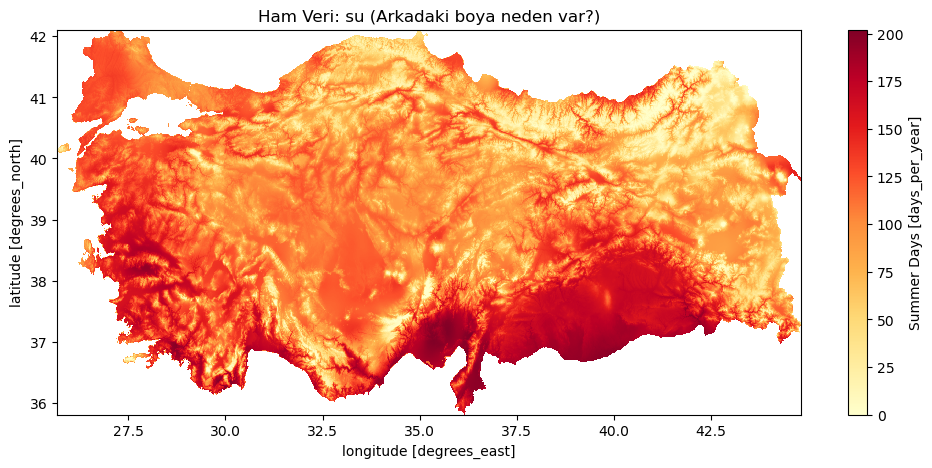

Veri Boyutu: (756, 2299)
NaN Değer Sayısı: 560798
Minimum Değer: 0.0
Maksimum Değer: 202.10000610351562


In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Senin dosyanın yolu
path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.nc"

# Veriyi açalım
ds = xr.open_dataset(path)
var_name = list(ds.data_vars)[0]
data = ds[var_name]

# 1. Çizim: Ham hali (Arkadaki boyayı burada göreceksin)
plt.figure(figsize=(12, 5))
data.plot(cmap="YlOrRd")
plt.title(f"Ham Veri: {var_name} (Arkadaki boya neden var?)")
plt.show()

# 2. Teşhis: NaN (Boş) değerler ne alemde?
print(f"Veri Boyutu: {data.shape}")
print(f"NaN Değer Sayısı: {np.isnan(data.values).sum()}")
print(f"Minimum Değer: {data.min().values}")
print(f"Maksimum Değer: {data.max().values}")

--- Veri Raporu ---
Değişken: su
Boyutlar: (756, 2299)
Max: 202.10000610351562, Min: 0.0
Sıfır olan piksel sayısı: 184
NaN (Boş) olan piksel sayısı: 560798


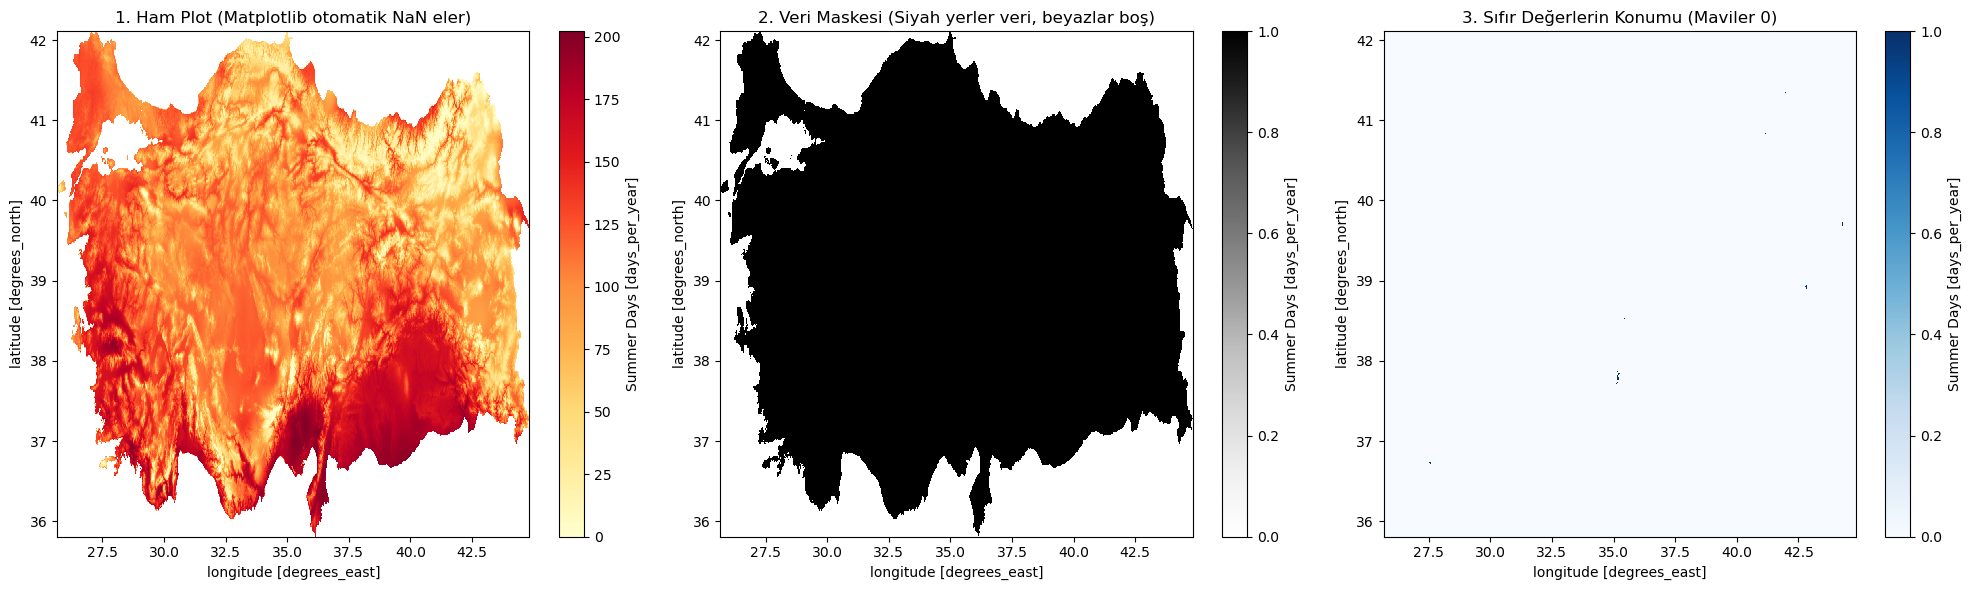

In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Dosya Yolu (Kendi bilgisayarına göre burayı teyit et abi)
file_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.nc"

if not os.path.exists(file_path):
    print("Dosya bulunamadı! Lütfen yolu kontrol et abi.")
    exit()

# 2. Veriyi Oku
ds = xr.open_dataset(file_path, mask_and_scale=True)
var_name = list(ds.data_vars)[0]
data = ds[var_name]

# Eğer zaman boyutu kaldıysa ortalamasını al
if 'time' in data.dims:
    data = data.mean(dim='time')

print(f"--- Veri Raporu ---")
print(f"Değişken: {var_name}")
print(f"Boyutlar: {data.shape}") # (756, 2299) gibi bir şey gelmeli
print(f"Max: {data.max().values}, Min: {data.min().values}")
print(f"Sıfır olan piksel sayısı: {np.count_nonzero(data.values == 0)}")
print(f"NaN (Boş) olan piksel sayısı: {np.isnan(data.values).sum()}")

# 3. Görselleştirme (Üç Farklı Bakış)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Sol: Ham Veri (Her şeyi olduğu gibi çizer)
data.plot(ax=axes[0], cmap="YlOrRd", add_colorbar=True)
axes[0].set_title("1. Ham Plot (Matplotlib otomatik NaN eler)")

# Orta: Sadece Veri Olan Yerler (Maske testi)
mask = data.notnull()
mask.plot(ax=axes[1], cmap="Greys")
axes[1].set_title("2. Veri Maskesi (Siyah yerler veri, beyazlar boş)")

# Sağ: Sıfır Değerleri (Senin dediğin o kritik 0'lar nerede?)
zeros = (data == 0)
zeros.plot(ax=axes[2], cmap="Blues")
axes[2].set_title("3. Sıfır Değerlerin Konumu (Maviler 0)")

plt.tight_layout()
plt.show()

In [30]:
import streamlit as st
import leafmap.foliumap as leafmap
import xarray as xr
import os
import numpy as np

st.set_page_config(layout="wide")
st.title("Streamlit Cloud - Raster Connectivity Test")

# 1. Path Test: Relative path kullanıyoruz
# Senin tree yapına göre historical altındaki bir dosyayı seçtim
file_path = "data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.nc"

if not os.path.exists(file_path):
    st.error(f"Dosya bulunamadı! Aranan yol: {file_path}")
else:
    st.success("Dosya başarıyla bulundu.")
    
    # 2. Data Loading
    ds = xr.open_dataset(file_path)
    # CDO sonrası hayalet zaman boyutunu ezmek için squeeze
    var_name = [v for v in ds.data_vars if v not in ['spatial_ref', 'time_bnds']][0]
    data = ds[var_name].squeeze()
    
    # Projeksiyonu mühürle (EPSG:4326)
    if data.rio.crs is None:
        data.rio.write_crs("EPSG:4326", inplace=True)

    st.write(f"Değişken: {var_name}")
    st.write(f"Veri Aralığı: {float(data.min())} - {float(data.max())}")

    # 3. Map Rendering
    m = leafmap.Map(center=[39, 35], zoom=6)
    
    # Renk paleti ekleyerek zorlayalım
    m.add_raster(data, layer_name="Test Layer", palette="Spectral_r", opacity=1.0)
    
    m.to_streamlit(height=600)

    # Veri özeti (Debug için)
    st.write("Xarray Dataset Summary:")
    st.text(str(ds))

2026-03-10 17:42:08.875 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 17:42:08.876 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 17:42:09.002 
  command:

    streamlit run /Users/emirtoker/miniforge3/envs/climate/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-10 17:42:09.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 17:42:09.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 17:42:09.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 17:42:09.005 Thread 'MainThread': missing ScriptRunContext! This warni

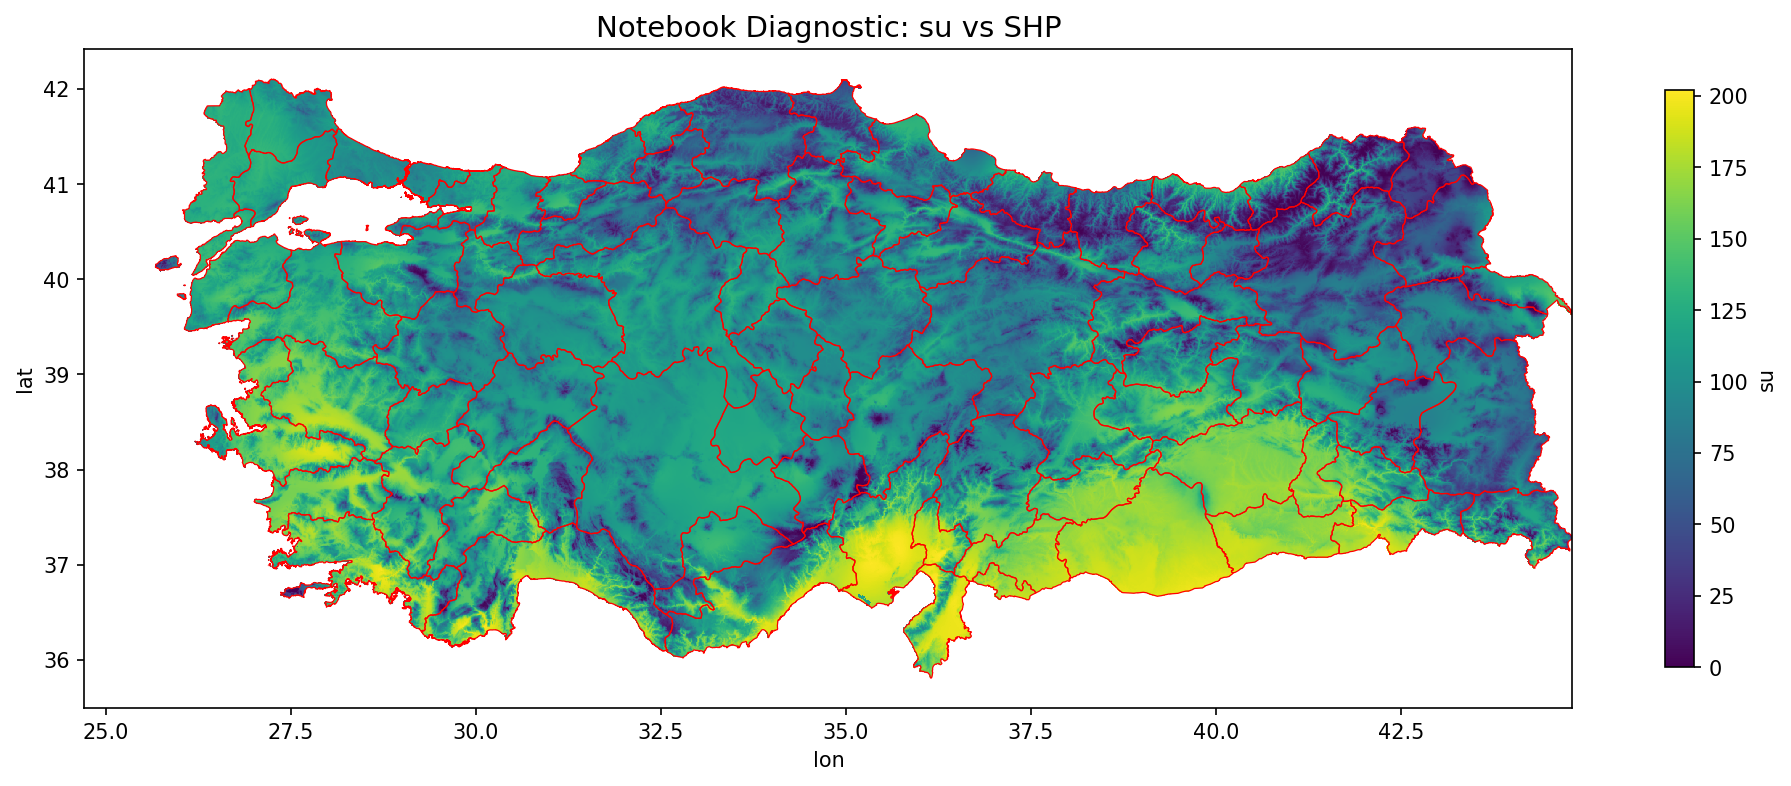

NC Koordinat İsimleri: lon, lat
NC Bounds (Extent)  : [25.670693621799984, 44.82069354519999, 35.81236060790002, 42.10402724940002]
SHP Bounds (Extent) : [25.668509  35.8084193 44.817931  42.1047857]


In [37]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. Yolları Tanımla
base_path = os.path.expanduser("~/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool")
nc_path = os.path.join(base_path, "data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.nc")
shp_path = os.path.join(base_path, "data/shapefiles/tur_adm_2025_ab_shp/tur_admbnda_adm1_2025.shp")

# 2. Verileri Yükle
ds = xr.open_dataset(nc_path)
var_name = [v for v in ds.data_vars if v not in ['spatial_ref', 'time_bnds']][0]
data = ds[var_name].squeeze()
if 'time' in data.dims: data = data.mean('time')

# Koordinat isimlerini otomatik yakala
lon_n = 'lon' if 'lon' in data.coords else ('x' if 'x' in data.coords else 'longitude')
lat_n = 'lat' if 'lat' in data.coords else ('y' if 'y' in data.coords else 'latitude')

shp = gpd.read_file(shp_path)

# 3. Görselleştirme
fig, ax = plt.subplots(figsize=(16, 10), dpi=150)

# Extent hesapla
extent = [float(data[lon_n].min()), float(data[lon_n].max()), 
          float(data[lat_n].min()), float(data[lat_n].max())]

# Veriyi çiz (origin='lower' genellikle NC verileri için daha doğrudur, eğer ters çıkarsa 'upper' yaparsın)
im = ax.imshow(data.values, extent=extent, cmap='viridis', origin='lower', interpolation='none')

# SHP sınırlarını ekle
shp.boundary.plot(ax=ax, color='red', linewidth=0.6, alpha=1)

# Renk çubuğu
plt.colorbar(im, ax=ax, label=var_name, shrink=0.5)

plt.title(f"Notebook Diagnostic: {var_name} vs SHP", fontsize=14)
plt.xlabel(lon_n)
plt.ylabel(lat_n)

plt.show()

# Sayısal kontrol
print(f"NC Koordinat İsimleri: {lon_n}, {lat_n}")
print(f"NC Bounds (Extent)  : {extent}")
print(f"SHP Bounds (Extent) : {shp.total_bounds}")

In [38]:
import streamlit as st
import leafmap.foliumap as leafmap
import xarray as xr
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import branca.colormap as cm
from folium.raster_layers import ImageOverlay

st.set_page_config(layout="wide")
st.title("Diagnostic Interactive Test (Milimetric Alignment)")

# 1. DOSYA YOLLARI
base_path = os.path.expanduser("~/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool")
nc_path = os.path.join(base_path, "data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.nc")
shp_path = os.path.join(base_path, "data/shapefiles/tur_adm_2025_ab_shp/tur_admbnda_adm1_2025.shp")

if os.path.exists(nc_path) and os.path.exists(shp_path):
    # 2. VERİ YÜKLEME
    ds = xr.open_dataset(nc_path)
    var_name = [v for v in ds.data_vars if v not in ['spatial_ref', 'time_bnds']][0]
    data = ds[var_name].squeeze()
    if 'time' in data.dims: data = data.mean('time')
    
    shp = gpd.read_file(shp_path)
    
    # 3. SIDEBAR (Sadece Colorbar Seçimi)
    st.sidebar.header("Settings")
    cmap_choice = st.sidebar.selectbox("Color Palette", ["viridis", "Spectral_r", "RdYlBu_r", "magma", "plasma"])
    alpha_val = st.sidebar.slider("Opacity", 0.0, 1.0, 0.7)
    
    # 4. HARİTA MOTORU
    m = leafmap.Map(center=[39, 35], zoom=6, tiles=None)
    
    # CSS: Pixelated rendering (Keskin pikseller)
    m.get_root().header.add_child(mpl.backend_bases.folium.Element("""
    <style> .leaflet-image-layer { image-rendering: pixelated !important; } </style>
    """))

    # SHP Katmanı (Siyah İnce Sınırlar)
    m.add_gdf(shp, layer_name="Boundaries", style={'color': 'black', 'fillOpacity': 0, 'weight': 0.8})

    # 5. RASTER TO IMAGEOVERLAY (Notebook'taki hizalamayı buraya taşıyoruz)
    lon_n = 'lon' if 'lon' in data.coords else ('x' if 'x' in data.coords else 'longitude')
    lat_n = 'lat' if 'lat' in data.coords else ('y' if 'y' in data_arr.coords else 'latitude')
    
    # Notebook'taki o milimetrik extent mantığı
    x_min, x_max = float(data[lon_n].min()), float(data[lon_n].max())
    y_min, y_max = float(data[lat_n].min()), float(data[lat_n].max())
    
    # Piksel çözünürlüğüne göre sınırları köşeye (edge) çekiyoruz
    res_x = (x_max - x_min) / (data.shape[1] - 1)
    res_y = (y_max - y_min) / (data.shape[0] - 1)
    
    # Folium Bounds: [[South, West], [North, East]]
    bnds = [[y_min - res_y/2, x_min - res_x/2], [y_max + res_y/2, x_max + res_x/2]]
    
    # Normalizasyon ve Renklendirme
    vmin, vmax = float(data.min()), float(data.max())
    norm = (data.values - vmin) / (vmax - vmin)
    norm = np.clip(norm, 0, 1)
    
    cmap = plt.get_cmap(cmap_choice)
    rgba = cmap(norm)
    rgba = np.flipud(rgba) # Kuzeyi yukarı al
    
    # Haritaya bas
    ImageOverlay(image=rgba, bounds=bnds, opacity=alpha_val, name="Climate Index").add_to(m)

    # 6. COLORBAR (Branca)
    colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, 256)]
    cmap_obj = cm.LinearColormap(colors=colors, vmin=vmin, vmax=vmax, caption=f"{var_name} Index")
    m.add_child(cmap_obj)

    # Haritayı ekrana bas
    m.to_streamlit(height=800)
    
    st.write(f"Diagnostic Info: NC Range [{vmin:.2f}, {vmax:.2f}] | Bounds: {bnds}")
else:
    st.error("Dosyalar bulunamadı! Lütfen base_path ayarını kontrol et.")

2026-03-10 19:04:00.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:00.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:00.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:00.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:01.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:01.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:01.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 19:04:01.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

AttributeError: module 'matplotlib.backend_bases' has no attribute 'folium'

In [41]:
import xarray as xr
import geopandas as gpd
import leafmap
import os
import numpy as np

# 1. YOLLAR
data_root = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data"
nc_file = os.path.join(data_root, "indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.nc")
shp_file = os.path.join(data_root, "shapefiles/tur_adm_2025_ab_shp/tur_admbnda_adm1_2025.shp")

# 2. VERİYİ OKU VE CRS MÜHÜRLE (Hata buradaydı)
ds = xr.open_dataset(nc_file)
var_name = [v for v in ds.data_vars if v not in ['spatial_ref', 'time_bnds']][0]
data = ds[var_name].squeeze()

# Burası kritik: Verinin içine CRS bilgisini zorla enjekte ediyoruz
data.rio.write_crs("EPSG:4326", inplace=True)

# SHP Oku
shp = gpd.read_file(shp_file)

# 3. HARİTA (Veriyi dosya yoluyla değil, xarray objesiyle veriyoruz)
m = leafmap.Map(center=[39, 35], zoom=6, tiles="OpenStreetMap")

# local-tileserver hatasını engellemek için array üzerinden ekliyoruz
m.add_raster(
    data, 
    layer_name="Index: " + var_name, 
    palette="viridis", 
    opacity=0.7
)

# SHP Ekle (Kırmızı)
m.add_gdf(
    shp, 
    layer_name="Boundaries", 
    style={'color': 'red', 'fillOpacity': 0, 'weight': 1.5}
)

m

Map(center=[38.958194, 35.2456935], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [43]:
import xarray as xr
import os
import glob

# YOLLAR
source_root = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data"
nc_files = glob.glob(os.path.join(source_root, "indices/**/*.nc"), recursive=True)

print(f"Toplam {len(nc_files)} dosya üzerinde işlem yapılıyor...")

for f in nc_files:
    try:
        # decode_coords="all" önemli, metadata'yı açar
        ds = xr.open_dataset(f, decode_coords="all")
        
        # CRS Mühürleme (EPSG:4326 - WGS84)
        # Sadece bu satır bile online taraftaki 'to_authority' hatasını bitirir
        ds.rio.write_crs("EPSG:4326", inplace=True)
        
        # Transform mühürü (Piksel çerçevesini sabitler)
        ds.rio.write_transform(inplace=True)
        
        # Orijinal ismin üzerine yazma işlemi
        temp_file = f + ".tmp"
        ds.to_netcdf(temp_file)
        ds.close()
        
        os.replace(temp_file, f)
        print(f"Başarıyla Mühürlendi: {os.path.basename(f)}")
        
    except Exception as e:
        print(f"Hata ({os.path.basename(f)}): {e}")

print("\nİşlem tamam! Şimdi online haritada 'bounds' hatası almamamız gerekiyor.")

Toplam 14 dosya üzerinde işlem yapılıyor...
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PRCPTOT_annual_total_precip.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_SU_summer_days.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PCD_passive_comfort_days.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_TR_tropical_nights.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_TR_tropical_nights.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_SU_summer_days.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PRCPTOT_annual_total_precip.nc
Başarıyla Mühürlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PCD_passive_comfort_days.nc
Başarıyla Mühürlendi: CHELSA_TR_yearly_2000_2014_DI_discomfort_index.nc
Başarıyla Mühürlendi: 

In [45]:
import xarray as xr
import os
import glob

# YOLLAR
source_root = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data"
nc_files = glob.glob(os.path.join(source_root, "indices/**/*.nc"), recursive=True)

print(f"Toplam {len(nc_files)} dosya işleniyor...")

for f in nc_files:
    try:
        # 1. Veriyi oku
        ds = xr.open_dataset(f, decode_coords="all")
        var_name = [v for v in ds.data_vars if v not in ['spatial_ref', 'time_bnds']][0]
        data = ds[var_name].squeeze()
        
        # 2. Önce mevcut koordinatları mühürle (WGS84)
        data.rio.write_crs("EPSG:4326", inplace=True)
        
        # 3. KRİTİK ADIM: Web Mercator'a (EPSG:3857) dönüştür
        # Bu işlem kuzeye kayma/uzama hatasını kalıcı olarak düzeltir
        data_reprojected = data.rio.reproject("EPSG:3857")
        
        # 4. GeoTIFF olarak kaydet
        tif_path = f.replace(".nc", ".tif")
        data_reprojected.rio.to_raster(tif_path)
        
        print(f"Başarıyla Çevrildi: {os.path.basename(tif_path)}")
        
    except Exception as e:
        print(f"Hata ({os.path.basename(f)}): {e}")

print("\nBütün dosyalar Web Mercator (.tif) olarak hazır!")

Toplam 14 dosya işleniyor...
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PRCPTOT_annual_total_precip.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_SU_summer_days.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PCD_passive_comfort_days.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_TR_tropical_nights.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_TR_tropical_nights.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_SU_summer_days.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PRCPTOT_annual_total_precip.tif
Başarıyla Çevrildi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PCD_passive_comfort_days.tif
Başarıyla Çevrildi: CHELSA_TR_yearly_2000_2014_DI_discomfort_index.tif
Başarıyla Çevrildi: CHELSA_TR_yearly_1995_2014

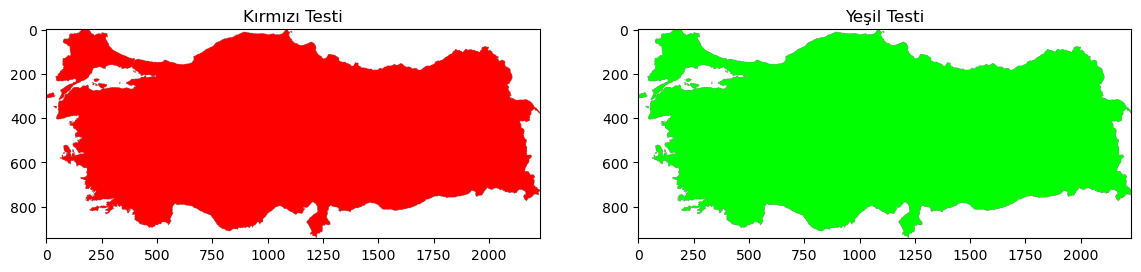

In [47]:
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# Senin sistemindeki tam yol (CHELSA SU Indeksi örneği üzerinden)
path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.tif"

if not os.path.exists(path):
    print("Dosya hala bulunamadı, lütfen klasörde terminal açıp 'pwd' yazarak yolu teyit et abi.")
else:
    # 1. TIF dosyasını oku
    raster = rioxarray.open_rasterio(path)
    # Band 1'i al ve squeezing yap (gereksiz boyutları at)
    data = raster.values[0]

    # NoData temizliği (Beyazlaşmayı/Şeffaflığı kontrol eden yer burası)
    # Tif içindeki NoData değerini (genelde -9999 veya nan) yakalayıp np.nan yapıyoruz
    data = np.where(data == raster.rio.nodata, np.nan, data)

    def create_rgba_image(data_array, color_hex):
        """
        RGBA matrisi oluşturma: Veri olan yere renk, olmayan yere 0 (şeffaf).
        """
        mask = ~np.isnan(data_array)
        rgba = np.zeros((*data_array.shape, 4))
        
        # Seçilen rengi RGBA'ya çevir (Örn: #FF0000 -> 1, 0, 0, 1)
        rgb_color = mpl.colors.to_rgba(color_hex)
        
        # Atama yapıyoruz
        rgba[mask] = rgb_color
        return rgba

    # TESTLER
    red_rgba = create_rgba_image(data, "#FF0000")   # Kırmızı
    green_rgba = create_rgba_image(data, "#00FF00") # Yeşil (Sidebar'da değiştirdiğini farz et)

    # Görselleştirme
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.imshow(red_rgba)
    ax1.set_title("Kırmızı Testi")
    ax2.imshow(green_rgba)
    ax2.set_title("Yeşil Testi")
    plt.show()

2026-03-11 09:50:59.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 09:50:59.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

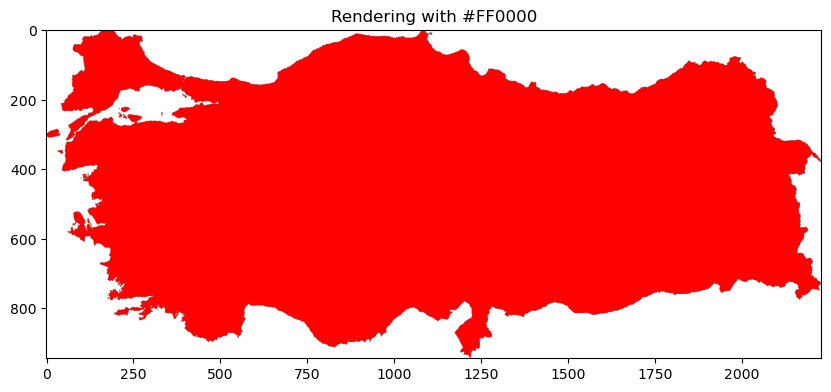

In [48]:
import streamlit as st
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import leafmap.foliumap as leafmap
from folium.raster_layers import ImageOverlay
import os

st.set_page_config(layout="wide")
st.title("Color Debugger: Where does the color go?")

# 1. TEST DOSYASI (Senin yolun)
tif_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/CHELSA_TR_yearly_1995_2014_SU_summer_days.tif"

if not os.path.exists(tif_path):
    st.error(f"Dosya bulunamadı: {tif_path}")
    st.stop()

# 2. SIDEBAR - RENK SEÇİMİ
st.sidebar.header("Color Selection")
selected_color = st.sidebar.color_picker("Choose a color", "#FF0000")
opacity = st.sidebar.slider("Opacity", 0.0, 1.0, 0.7)

# 3. VERİ OKUMA
raster = rioxarray.open_rasterio(tif_path)
data = raster.values[0]
data_clean = np.where(data == raster.rio.nodata, np.nan, data)

# --- DEBUG BİLGİLERİ (BURASI ÇOK KRİTİK) ---
st.subheader("Diagnostic Information")
col1, col2, col3 = st.columns(3)

with col1:
    st.info(f"**Selected Hex:** {selected_color}")
    st.write(f"Type: `{type(selected_color)}`")

with col2:
    # Hex'ten RGBA'ya dönüşüm testi
    try:
        rgba_tuple = mpl.colors.to_rgba(selected_color)
        st.success(f"**Converted RGBA:** {rgba_tuple}")
    except Exception as e:
        st.error(f"Conversion Error: {e}")

with col3:
    st.warning(f"**Data Stats:**")
    st.write(f"Min: {np.nanmin(data_clean):.2f}")
    st.write(f"Max: {np.nanmax(data_clean):.2f}")

# 4. RGBA MATRİSİ OLUŞTURMA (Jupyter'deki mantık)
mask = ~np.isnan(data_clean)
rgba_matrix = np.zeros((*data_clean.shape, 4))
rgba_matrix[mask] = mpl.colors.to_rgba(selected_color)

# 5. HARİTA ÜZERİNDE GÖSTERİM
st.subheader("Interactive Map Test")

# Bounds hesapla (Map engine'deki mantık)
data_4326 = raster.rio.reproject("EPSG:4326")
left, bottom, right, top = data_4326.rio.bounds()
bnds = [[bottom, left], [top, right]]

m = leafmap.Map(center=[39, 35], zoom=6)

# ImageOverlay ekle
ImageOverlay(
    image=rgba_matrix,
    bounds=bnds,
    opacity=opacity,
    name="Debug Layer"
).add_to(m)

m.to_streamlit(height=600)

# 6. MATPLOTLIB İLE HAM KONTROL
st.subheader("Raw Matplotlib Render (Backup Check)")
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(rgba_matrix)
ax.set_title(f"Rendering with {selected_color}")
st.pyplot(fig)

In [1]:
shp_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/shapefiles/tur_adm_2025_ab_shp/tur_admbnda_adm1_2025.shp"


In [50]:
shp = gpd.read_file(shp_path).to_crs("EPSG:4326")


In [66]:
shp.ADM1_TR.values[39]

'İSTANBUL'

In [3]:
import xarray as xr
import geopandas as gpd
import rioxarray
import os
shp = gpd.read_file(shp_path).to_crs("EPSG:4326")


In [4]:
shp.ADM1_TR.values[39]

'İSTANBUL'

--- Dosya Analizi: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.tif ---
Koordinat Sistemi (CRS): EPSG:3857
Çözünürlük (Res): (957.7001270643821, -957.7001270643825)
Boyutlar (Shape): (1, 981, 2290)
Sınırlar (Bounds): (2816367.5646181945, 4266499.653304342, 5009500.85559563, 5206003.477954502)
NoData Değeri: nan
Veri Tipi: float32
Min Değer: 0.05000000074505806
Max Değer: 163.9499969482422
Ortalama: 79.40020751953125


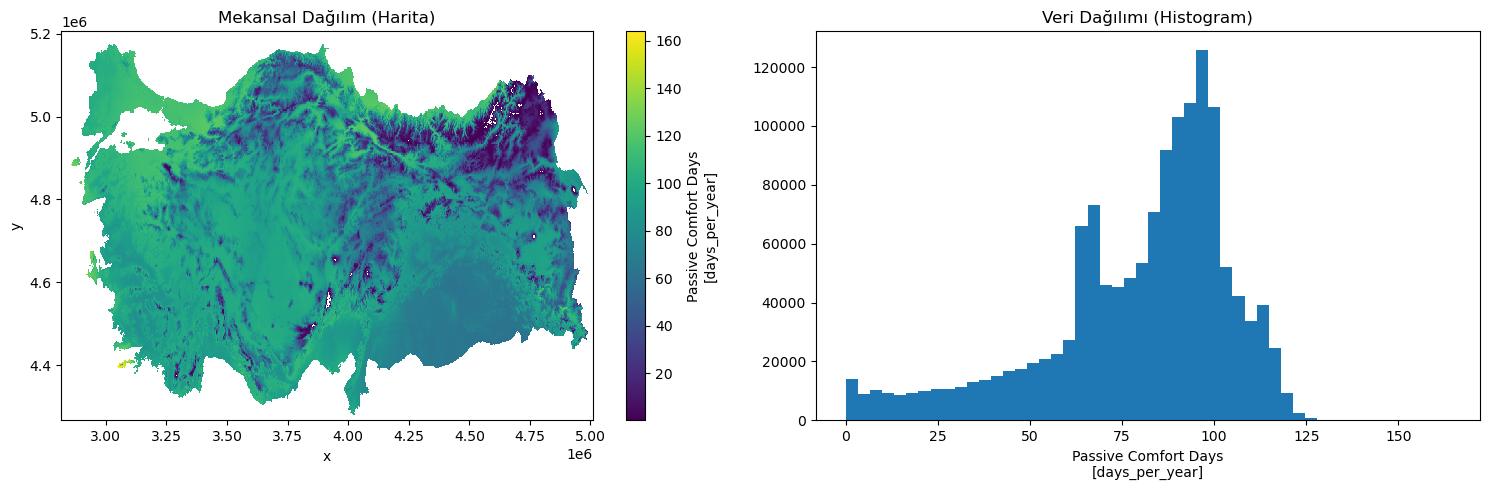

In [1]:
import os
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt

# Senin verdiğin ana yol
chelsa_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA"

# Örnek olarak bir tanesini seçelim (PCD seçtim)
target_file = "CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.tif"
full_path = os.path.join(chelsa_path, target_file)

# Dosyayı rioxarray ile açalım
ds = rioxarray.open_rasterio(full_path, mask_and_scale=True)

# 1. TEMEL ÖZELLİKLERİ YAZDIR
print(f"--- Dosya Analizi: {target_file} ---")
print(f"Koordinat Sistemi (CRS): {ds.rio.crs}")
print(f"Çözünürlük (Res): {ds.rio.resolution()}")
print(f"Boyutlar (Shape): {ds.shape}")
print(f"Sınırlar (Bounds): {ds.rio.bounds()}")
print(f"NoData Değeri: {ds.rio.nodata}")
print(f"Veri Tipi: {ds.dtype}")

# 2. İSTATİSTİKSEL ÖZET
if hasattr(ds, 'band'):
    data = ds.sel(band=1)
else:
    data = ds

print(f"Min Değer: {data.min().values}")
print(f"Max Değer: {data.max().values}")
print(f"Ortalama: {data.mean().values}")

# 3. GÖRSEL KONTROL (Harita ve Histogram)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

data.plot(ax=ax1, cmap="viridis")
ax1.set_title("Mekansal Dağılım (Harita)")

data.plot.hist(ax=ax2, bins=50)
ax2.set_title("Veri Dağılımı (Histogram)")

plt.tight_layout()
plt.show()

In [2]:
import os
import rioxarray
import xarray as xr

# 1. Klasör Yollarını Tanımla
base_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA"
output_path = os.path.join(base_path, "data_format_cog")

# Çıktı klasörünü kontrol et ve yoksa oluştur
if not os.path.exists(output_path):
    os.makedirs(output_path)

print(f"🚀 İşlem başladı! Sadece .tif dosyaları işleniyor...")
print(f"📂 Hedef Klasör: {output_path}\n")

# 2. Sadece .tif Uzantılı Dosyaları Döngüye Al
for file_name in os.listdir(base_path):
    # Sadece ana klasördeki .tif dosyalarını al (kendi oluşturduğumuz klasörü veya gizli dosyaları geç)
    if file_name.endswith(".tif") and os.path.isfile(os.path.join(base_path, file_name)):
        print(f"⌛ İşleniyor: {file_name}")
        full_in = os.path.join(base_path, file_name)
        
        # Çıktı dosya adı (karışıklık olmasın diye sonuna _cog ekliyoruz)
        full_out = os.path.join(output_path, file_name.replace(".tif", "_cog.tif"))
        
        try:
            # Veriyi aç
            ds = rioxarray.open_rasterio(full_in, mask_and_scale=True)
            
            # --- ADIM 1: TİME BOYUTUNDAN KURTULMA ---
            if 'time' in ds.dims:
                ds = ds.mean(dim='time')
            
            # --- ADIM 2: BAND BOYUTUNU DÜZLEŞTİRME (2D yapma) ---
            if 'band' in ds.dims:
                ds = ds.sel(band=1)

            # --- ADIM 3: PROJEKSİYON KONTROLÜ (Zaten 3857 demiştin ama garantiye alalım) ---
            if ds.rio.crs is None:
                ds.rio.write_crs("EPSG:3857", inplace=True)
            elif ds.rio.crs != "EPSG:3857":
                ds = ds.rio.reproject("EPSG:3857")

            # --- ADIM 4: COG FORMATINDA KAYDET ---
            # tiled=True + overviews=True: Slider hızını artıran asıl sihir burası
            ds.rio.to_raster(
                full_out,
                driver="COG",
                tiled=True,
                blocksize=256,
                compress="DEFLATE",
                overviews=True
            )
            print(f"✅ Optimize Edildi: {file_name}")
            
        except Exception as e:
            print(f"❌ Hata oluştu ({file_name}): {e}")

print(f"\n🔥 İşlem başarıyla tamamlandı! Artık haritada bu dosyaları kullanabiliriz.")

🚀 İşlem başladı! Sadece .tif dosyaları işleniyor...
📂 Hedef Klasör: /Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog

⌛ İşleniyor: CHELSA_TR_yearly_1995_2014_SU_summer_days.tif
✅ Optimize Edildi: CHELSA_TR_yearly_1995_2014_SU_summer_days.tif
⌛ İşleniyor: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.tif
✅ Optimize Edildi: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days.tif
⌛ İşleniyor: CHELSA_TR_yearly_1995_2014_TR_tropical_nights.tif
✅ Optimize Edildi: CHELSA_TR_yearly_1995_2014_TR_tropical_nights.tif
⌛ İşleniyor: CHELSA_TR_yearly_2000_2009_UTCI_universal_thermal_comfort_index.tif
✅ Optimize Edildi: CHELSA_TR_yearly_2000_2009_UTCI_universal_thermal_comfort_index.tif
⌛ İşleniyor: CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip.tif
✅ Optimize Edildi: CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip.tif
⌛ İşleniyor: CHELSA_TR_yearly_2000_2014_DI_di

In [4]:
import os
import rioxarray
import rasterio # Doğrudan ana kütüphaneyi çağıralım

check_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog"

files = [f for f in os.listdir(check_path) if f.endswith(".tif")]
if files:
    test_file = os.path.join(check_path, files[0])
    
    print(f"🧐 Kontrol Ediliyor: {files[0]}")
    
    with rasterio.open(test_file) as src:
        # 1. Katman sayısını ve boyutları kontrol et
        print(f"📏 Katman Sayısı: {src.count}")
        print(f"📐 Genişlik/Yükseklik: {src.width}x{src.height}")
        
        # 2. Piramit yapı (Overviews) var mı?
        # Genelde ilk bandın overviews listesine bakılır
        ov = src.overviews(1)
        print(f"🚀 Piramit Seviyeleri: {ov}")
        
        if len(ov) > 0:
            print("\n✅ TERTEMİZ: Dosya gerçek bir COG. Zoom yaparken uçacak!")
        else:
            print("\n⚠️ DİKKAT: Piramitler eksik. Harita zoom yaparken biraz hantal kalabilir.")
            
        # 3. Blok yapısı (Tiling)
        print(f"📦 Blok Yapısı: {src.block_shapes[0]}")
        if src.is_tiled:
            print("✅ Tiling Aktif: Sadece gerekli kareler okunacak.")
else:
    print("❌ Klasörde dosya bulunamadı!")

🧐 Kontrol Ediliyor: CHELSA_TR_yearly_1995_2014_TR_tropical_nights_cog.tif
📏 Katman Sayısı: 1
📐 Genişlik/Yükseklik: 2229x944
🚀 Piramit Seviyeleri: [2, 4, 8, 16]

✅ TERTEMİZ: Dosya gerçek bir COG. Zoom yaparken uçacak!
📦 Blok Yapısı: (256, 256)
✅ Tiling Aktif: Sadece gerekli kareler okunacak.


🖼️ Görselleştiriliyor: CHELSA_TR_yearly_1995_2014_TR_tropical_nights_cog.tif


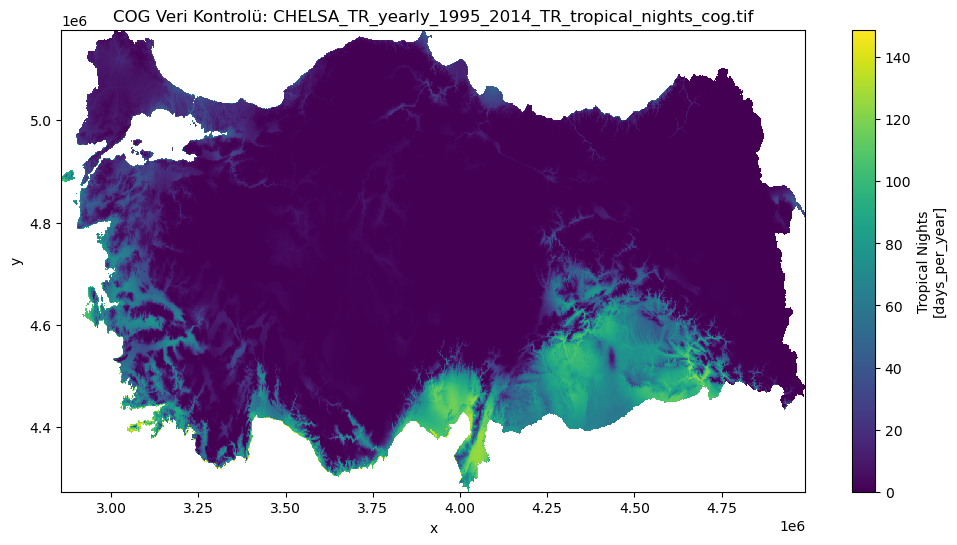

📊 Veri Aralığı: 0.0 - 148.85000610351562
📐 Matris Şekli (Shape): (1, 944, 2229)


In [5]:
import os
import rioxarray
import matplotlib.pyplot as plt
import numpy as np

# Yeni dosyaların yolu
check_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog"

files = [f for f in os.listdir(check_path) if f.endswith(".tif")]

if files:
    test_file = os.path.join(check_path, files[0])
    print(f"🖼️ Görselleştiriliyor: {files[0]}")
    
    # Veriyi aç
    ds = rioxarray.open_rasterio(test_file, mask_and_scale=True)
    
    # Boyut kontrolü ve görselleştirme
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Eğer 3 boyutluysa (band, y, x), ilk bandı alıp çizdir
    if len(ds.shape) == 3:
        plot_data = ds.isel(band=0)
    else:
        plot_data = ds
        
    plot_data.plot(ax=ax, cmap="viridis")
    plt.title(f"COG Veri Kontrolü: {files[0]}")
    plt.show()
    
    print(f"📊 Veri Aralığı: {np.nanmin(ds.values)} - {np.nanmax(ds.values)}")
    print(f"📐 Matris Şekli (Shape): {ds.shape}")
else:
    print("❌ Klasörde dosya bulunamadı!")

In [6]:
import os
import rioxarray
import numpy as np
import json

# Hedef klasör yolu
target_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog"

# Sadece .tif uzantılı dosyaları alıyoruz (data_loader'daki list_available_indices ile aynı mantık)
files = sorted([f for f in os.listdir(target_path) if f.endswith(".tif")])

stats_dict = {}

if not files:
    print("HATA: Klasörde .tif dosyası bulunamadı.")
else:
    print(f"Toplam {len(files)} dosya için istatistikler çıkarılıyor...")

    for file_name in files:
        full_path = os.path.join(target_path, file_name)
        
        try:
            # rioxarray ile aç (mask_and_scale NoData'ları NaN yapar, hesaplama doğru olur)
            ds = rioxarray.open_rasterio(full_path, mask_and_scale=True)
            
            # Matrisin içindeki gerçek veriyi al
            data_values = ds.values[0] if len(ds.values.shape) == 3 else ds.values
            
            # İstatistikleri hesapla
            v_min = float(np.nanmin(data_values))
            v_max = float(np.nanmax(data_values))
            
            # DOSYA ADINI HİÇ DEĞİŞTİRMEDEN KEY OLARAK KULLAN
            # Bu sayede data_loader.py içindeki file_name ile %100 eşleşir
            stats_dict[file_name] = {
                "min": v_min,
                "max": v_max
            }
            
            print(f"İşlendi: {file_name}")
            
        except Exception as e:
            print(f"Hata ({file_name}): {e}")

    # stats.json dosyasını aynı klasöre kaydet
    json_path = os.path.join(target_path, "stats.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(stats_dict, f, indent=4)

    print("-" * 30)
    print("İŞLEM TAMAMLANDI.")
    print(f"JSON Dosyası: {json_path}")

Toplam 6 dosya için istatistikler çıkarılıyor...
İşlendi: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_cog.tif
İşlendi: CHELSA_TR_yearly_1995_2014_PRCPTOT_annual_total_precip_cog.tif
İşlendi: CHELSA_TR_yearly_1995_2014_SU_summer_days_cog.tif
İşlendi: CHELSA_TR_yearly_1995_2014_TR_tropical_nights_cog.tif
İşlendi: CHELSA_TR_yearly_2000_2009_UTCI_universal_thermal_comfort_index_cog.tif
İşlendi: CHELSA_TR_yearly_2000_2014_DI_discomfort_index_cog.tif
------------------------------
İŞLEM TAMAMLANDI.
JSON Dosyası: /Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog/stats.json


📄 DOSYA ANALİZİ: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_cog.tif
📏 Boyutlar (Dimensions): ('band', 'y', 'x')
📐 Şekil (Shape): (1, 981, 2290)
🌍 Projeksiyon (CRS): EPSG:3857
📍 Sınırlar (Bounds): (2816367.5646181945, 4266499.653304342, 5009500.85559563, 5206003.477954502)
🔳 Blok Yapısı (Tiling): N/A
📦 Veri Tipi (Dtype): float32

🏷️  ÖZNİTELİKLER (Attributes):
 - approach: 18°C < TG < 25°C
 - cell_methods: time: mean
 - description: Number of days where daily mean temperature is between 18°C and 25°C (thermal comfort range).
 - long_name: Passive Comfort Days
 - statistical_summary: Min:0.0, Q1:64.0, Med:82.0, Q3:98.0, Max:204.0, Mean:73.19
 - units: days_per_year
 - used_variables: tas
 - AREA_OR_POINT: Area

📊 İSTATİSTİKLER:
 - Gerçek Min: 0.05
 - Gerçek Max: 163.95
 - Geçerli Piksel Sayısı: 1412315


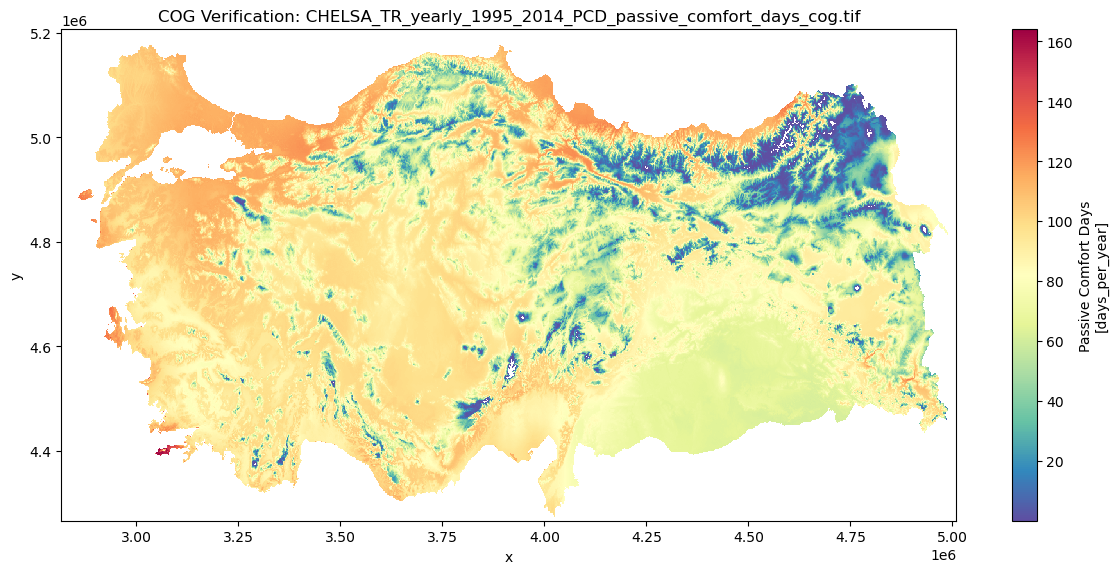

In [7]:
import rioxarray
import os
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolu (Listendeki ilk dosyayı seçiyoruz)
folder_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog"
file_name = "CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_cog.tif"
full_path = os.path.join(folder_path, file_name)

# 1. DOSYAYI AÇ
# mask_and_scale=True ile NoData'ları (denizler vs.) NaN yapıyoruz
ds = rioxarray.open_rasterio(full_path, mask_and_scale=True)

# 2. TEKNİK ANALİZ (KİMLİK KARTI)
print(f"{'='*50}")
print(f"📄 DOSYA ANALİZİ: {file_name}")
print(f"{'='*50}")
print(f"📏 Boyutlar (Dimensions): {ds.dims}")
print(f"📐 Şekil (Shape): {ds.shape}")
print(f"🌍 Projeksiyon (CRS): {ds.rio.crs}")
print(f"📍 Sınırlar (Bounds): {ds.rio.bounds()}")
print(f"🔳 Blok Yapısı (Tiling): {ds.encoding.get('chunks', 'N/A')}")
print(f"📦 Veri Tipi (Dtype): {ds.dtype}")

# 3. ATTRIBUTES (Öznitelikler)
print(f"\n🏷️  ÖZNİTELİKLER (Attributes):")
for key, val in ds.attrs.items():
    print(f" - {key}: {val}")

# 4. İSTATİSTİKSEL KONTROL
data_array = ds.values[0]
print(f"\n📊 İSTATİSTİKLER:")
print(f" - Gerçek Min: {np.nanmin(data_array):.2f}")
print(f" - Gerçek Max: {np.nanmax(data_array):.2f}")
print(f" - Geçerli Piksel Sayısı: {np.count_nonzero(~np.isnan(data_array))}")

# 5. GÖRSELLEŞTİRME
plt.figure(figsize=(12, 6))
ds.sel(band=1).plot(cmap="Spectral_r")
plt.title(f"COG Verification: {file_name}")
plt.tight_layout()
plt.show()

--------------------------------------------------
DOSYA: CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_cog.tif
--------------------------------------------------
Boyutlar (Dimensions): ('band', 'y', 'x')
Şekil (Shape): (1, 981, 2290)
Projeksiyon (CRS): EPSG:3857
Veri Tipi (Dtype): float32

ÖZNİTELİKLER (Attributes):
 - approach: 18°C < TG < 25°C
 - cell_methods: time: mean
 - description: Number of days where daily mean temperature is between 18°C and 25°C (thermal comfort range).
 - long_name: Passive Comfort Days
 - statistical_summary: Min:0.0, Q1:64.0, Med:82.0, Q3:98.0, Max:204.0, Mean:73.19
 - units: days_per_year
 - used_variables: tas
 - AREA_OR_POINT: Area


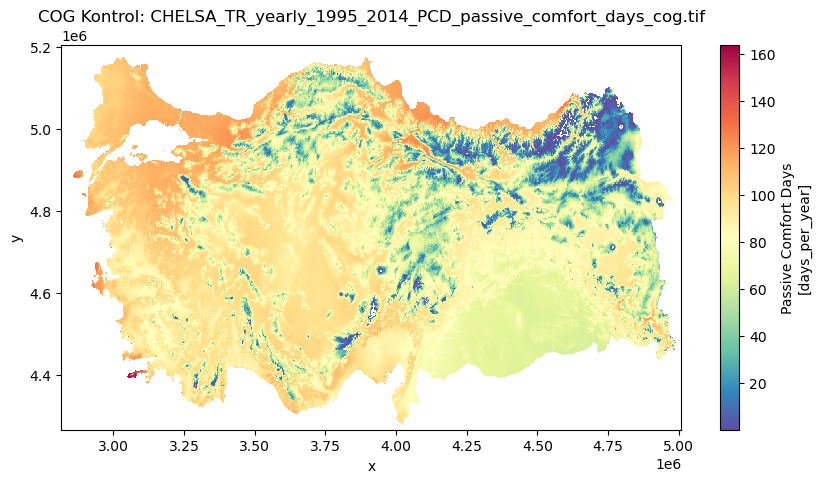

In [8]:
import rioxarray
import os
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolu
folder_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/historical/climatology/1km/CHELSA/data_format_cog"
file_name = "CHELSA_TR_yearly_1995_2014_PCD_passive_comfort_days_cog.tif"
full_path = os.path.join(folder_path, file_name)

# 1. DOSYAYI AÇ
ds = rioxarray.open_rasterio(full_path, mask_and_scale=True)

# 2. TEKNİK ÖZELLİKLER
print("-" * 50)
print(f"DOSYA: {file_name}")
print("-" * 50)
print(f"Boyutlar (Dimensions): {ds.dims}")
print(f"Şekil (Shape): {ds.shape}")
print(f"Projeksiyon (CRS): {ds.rio.crs}")
print(f"Veri Tipi (Dtype): {ds.dtype}")

# 3. ATTRIBUTES (Öznitelikler)
print("\nÖZNİTELİKLER (Attributes):")
if ds.attrs:
    for key, val in ds.attrs.items():
        print(f" - {key}: {val}")
else:
    print(" - Öznitelik bulunamadı.")

# 4. GÖRSELLEŞTİRME
plt.figure(figsize=(10, 5))
# Band 1'i seçip çizdiriyoruz (Zaten tek band)
ds.sel(band=1).plot(cmap="Spectral_r")
plt.title(f"COG Kontrol: {file_name}")
plt.show()

In [9]:
import os
import rioxarray
import numpy as np
import json

# Hedef klasör yolu
target_path = "/Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/sum_CHELSA_GCMs/climatology/SSP245"

# Sadece .tif uzantılı dosyaları alıyoruz
files = sorted([f for f in os.listdir(target_path) if f.endswith(".tif")])

stats_dict = {}

# Dosya adından birimi tahmin eden küçük bir sözlük (Ph.D. dokunuşu)
unit_map = {
    "PCD": "days/year",
    "PRCPTOT": "mm/year",
    "SU": "days/year",
    "TR": "days/year"
}

if not files:
    print("HATA: Klasörde .tif dosyası bulunamadı.")
else:
    print(f"Toplam {len(files)} dosya işleniyor...")

    for file_name in files:
        full_path = os.path.join(target_path, file_name)
        
        try:
            # rioxarray ile aç (NoData -> NaN dönüşümü ile)
            ds = rioxarray.open_rasterio(full_path, mask_and_scale=True)
            
            # Matris verisini al
            data_values = ds.values[0] if len(ds.values.shape) == 3 else ds.values
            
            # İstatistikleri hesapla
            v_min = float(np.nanmin(data_values))
            v_max = float(np.nanmax(data_values))
            
            # Birimi belirle
            detected_unit = ""
            for key in unit_map:
                if key in file_name:
                    detected_unit = unit_map[key]
                    break
            
            # JSON yapısı (Dosya adını tam eşleşme için key yapıyoruz)
            stats_dict[file_name] = {
                "min": round(v_min, 2),
                "max": round(v_max, 2),
                "unit": detected_unit
            }
            
            print(f"İşlendi: {file_name}")
            
        except Exception as e:
            print(f"Hata ({file_name}): {e}")

    # stats.json dosyasını kaydet
    json_path = os.path.join(target_path, "stats.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(stats_dict, f, indent=4)

    print("-" * 30)
    print(f"JSON Dosyası Oluşturuldu: {json_path}")
    print("tamamlandı")

Toplam 8 dosya işleniyor...
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PCD_passive_comfort_days.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_PRCPTOT_annual_total_precip.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_SU_summer_days.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2041-2060_delta_1995_2014_TR_tropical_nights.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PCD_passive_comfort_days.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_PRCPTOT_annual_total_precip.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_SU_summer_days.tif
İşlendi: CHELSA_sum_GCMs_Ensemble_TR_yearly_2081-2100_delta_1995_2014_TR_tropical_nights.tif
------------------------------
JSON Dosyası Oluşturuldu: /Users/emirtoker/Desktop/Proje_Tubitak_Bap/Iklim_Mimarlik_Projesi/Script/Python/climate_indices_map_tool/data/indices/sum_CHELSA_GCMs/climatology/SSP